# Hoja de Trabajo 2 - Markov Decision Process
### José Antonio Mérida Castejón - Carné 201105

Este Notebook corresponde al Task 2 de la tarea Hoja de Trabajo 2, consiste en la implementación del entorno "Frozen Lake" dónde el agente debe cruzar un lago congelado. Se tiene un grid, pero el hielo es resbaladizo y al realizar un movimiento puede parar en múltiples posiciones.

### Prompts

Cumpliendo con las reglas del laboratorio, utilicé IA generativa para generar las gráficas con Matplotlib / Seaborn. Los prompts consisten en:

[Contexto] Eg. I have a weight vector w_final, a bias b_final, and two DFs of training values x_train and y_train.

[Task] Eg. I need to graph the 2D points from x_train colored by y_train (binary classification) as there's going to be concentric points. Then, I'll need to graph the decision boundary for the model on top of it.

Esto funciona porque se explica al inicio los objetos con los que se están trabajando, así se evitan errores de compatibilidad etc. Adicionalmente, siendo descriptivos y concretos con el task se deja poca "interpretabilidad" donde la IA pueda tomar alguna decisión "tonta".

Adicionalmente, al ir iterando busco ser lo más específico posible con los objetos que se están trabajando o dar alguna guía lo más "bajo nivel posible". Por ejemplo,

"I'll need the plot to fill the background above / under the decision threshold to identify the positive / negative class, no other changes"

También, como preferencia personal hago la mayoría de cosas "a manita" pero ocupo la ayuda ocasional para recordar sintaxis / documentación. Esto incluye algunas ecuaciones en LaTeX dentro de los bloques de Markdown, dónde pueden ser algo complicadas o funciones de Numpy que no me recuerde. También para generarme el Grid de 4x4, no tengo originalidad.

### Task 2.1 - Modelado del MDP

Iniciando con el modelado, vamos a definir lo siguiente dentro de la clase `FrozenLakeMDP`
* **Estados**: Conjunto de 16 estados (0 a 15), dónde pueden ser
    - S: Start, el punto de inicio
    - F: Frozen, puntos congelados / transitables
    - H: Hoole, el juego se acaba al caer en el lago.
    - G: Goal, la meta a dónde queremos llegar.
* **Acciones**: N, E, S, W representando los 4 puntos cardinales North, East, South, West.
* **Transición $T(s, a, s')$**: Probabilidad de terminar en $s'$ dada una acción $a$ en $s$, en este caso la implementación calcula los siguientes estados, el reward y la probabilidad para un estado y acción para facilitar cálculos posteriores.
* **Recompensa $R(s, a, s')$**: Premio de la transición ($1.0$ para Meta, $0.0$ de lo contrario), en este caso se calcula únicamente basado en s y s' ya que se utiliza en T(s, a, s') internamente
* **IsEnd(s)**: Determina si el juego terminó (meta u hoyo)

In [17]:
class FrozenLakeMDP:
    # Initialize state, actions and grid
    def __init__(self):
        # 16 states for a 4x4 grid
        self.n_states = 16
    
        # Movement North, South, East or West
        self.actions = ['N', 'S', 'E', 'W']
    
        # Game grid. S = Start, G = Goal, F = Frozen (Transitable), H = Hole (Game over)
        self.grid = [
            'S', 'F', 'F', 'F',
            'F', 'H', 'F', 'H',
            'F', 'F', 'F', 'H',
            'H', 'F', 'F', 'G'
        ] # Numbered 0-15, going left to right then top to bottom

        # Terminals mean game ends, values hard-coded from grid
        self.terminals = [5, 7, 11, 12, 15]

    # Verify if game's done
    def goal_test(self, s):
        return s in self.terminals

    # Get next state based on current state and move
    def _get_next_state(self, s, move):
        # Get row and column by state number
        row = s // 4
        col = s % 4
        
        # Adjust row or column per possible move
        if move == 'N': row = max(0, row - 1)
        elif move == 'S': row = min(3, row + 1)
        elif move == 'E': col = min(3, col + 1)
        elif move == 'W': col = max(0, col - 1)
        
        # Return state by number
        return row * 4 + col

    # Get transitions based on current state and action
    def get_transitions(self, s, a):
        # Game over if s is terminal
        if self.goal_test(s):
            return [(1.0, s, 0.0)]

        # Rule: Any direction there's a 1/3 chance of going in the desired direction,
        # 1/3 of going any other perpendicular direction.
        moves = []
        # For North or South 1/3 we go East or West
        if a in ['N', 'S']:
            moves = [(1/3, a), (1/3, 'E'), (1/3, 'W')]
        # For East or West 1/3 we go North or South
        else:
            moves = [(1/3, a), (1/3, 'N'), (1/3, 'S')]

        # For every possible move, get next state and reward
        transitions = []
        for prob, move in moves:
            # Get next state
            s_prime = self._get_next_state(s, move)
            reward = self.get_reward(s, s_prime)
            transitions.append((prob, s_prime, reward))

        return transitions
    
    # Get reward for state
    def get_reward(self, s, s_prime):
        # 1 if Goal, 0 otherwise
        if self.grid[s_prime] == 'G' and self.grid[s] != 'G':
            return 1.0
        
        return 0.0

### Task 2.2 - Algoritmo de Iteración de Valores (Value Iteration)

La función se implementó de la siguiente manera:
 
**Inicialización**: Se define el vector de utilidades inicial $V^{(0)}(s) = 0$ para todos los estados.

**Ecuación de Bellman**: En cada iteración, se calcula $V_{k+1}(s) = \max_a \sum_{s'} T(s,a,s') [R(s,a,s') + \gamma V_k(s')]$

**Convergencia**: El bucle continúa hasta que el cambio máximo entre iteraciones sea menor a $\epsilon$.

**Factor de Descuento**: Se utiliza $\gamma = 0.9$ para balancear la importancia de recompensas futuras

In [18]:
import numpy as np

# Value iteration algorithm implementation using vectorized math
def value_iteration(mdp, gamma=0.9, epsilon=1e-5):
    # Initialize utility vector
    V = np.zeros(mdp.n_states)
    
    while True:
        delta = 0
        V_new = np.copy(V)
        
        for s in range(mdp.n_states):
            # Skip terminal states
            if mdp.goal_test(s):
                continue
                
            action_values = []
            for a in mdp.actions:
                # Fetch transitions for current state and action
                transitions = mdp.get_transitions(s, a)
                
                # Unpack transitions into NumPy arrays (Vectors)
                probs = np.array([t[0] for t in transitions])
                s_primes = np.array([t[1] for t in transitions])
                rewards = np.array([t[2] for t in transitions])
                
                # Bellman Equation, sum of probabilities * (rewards + gamma)
                v_a = np.sum(probs * (rewards + gamma * V[s_primes]))
                
                action_values.append(v_a)
                
            # Update utility vector with the highest action value
            V_new[s] = np.max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))
            
        V = V_new
        
        # Convergence check
        if delta < epsilon:
            break
            
    return V

# Initialize and run
mdp = FrozenLakeMDP()
V_optimal = value_iteration(mdp, gamma=0.9)

### Task 2.3 - Extracción de Política

Este algoritmo calcula la política óptima $\pi_{opt}(s)$ mediante la lectura de los valores $Q_{opt}$. Calcula la utilidad máxima de cada acción para cada estado, y posteriormente retorna la acción. Ya teniendo los cálculos utilizando Bellman, podemos ser "greedy" y buscar la acción óptima un paso hacia adelante.

In [ ]:
# Extract the optimal policy
def extract_policy(mdp, V, gamma=0.9):
    policy = [''] * mdp.n_states
    
    for s in range(mdp.n_states):
        # Keep grid layout for terminals
        if mdp.goal_test(s):
            policy[s] = mdp.grid[s]
            continue
            
        best_val = -float('inf')
        best_action = ''
        
        for a in mdp.actions:
            v_a = 0
            # Calculate expected utility for current action
            for prob, s_prime, reward in mdp.get_transitions(s, a):
                # Q = Probability of Reaching s' & Reward in s' + Discount Factor
                v_a += prob * (reward + gamma * V[s_prime])
                
            # Maximize expected utility
            if v_a > best_val:
                best_val = v_a
                best_action = a
                
        # Store action
        policy[s] = best_action
        
    return policy

# Execute policy extraction
optimal_policy = extract_policy(mdp, V_optimal)

### Task 2.3 - Visualización
Aquí simplemente mostramos los resultados, lado a lado tenemos las acciones óptimas en cada estado al igual que un mapa de calor que representa el "valor" de cada uno de los estados.

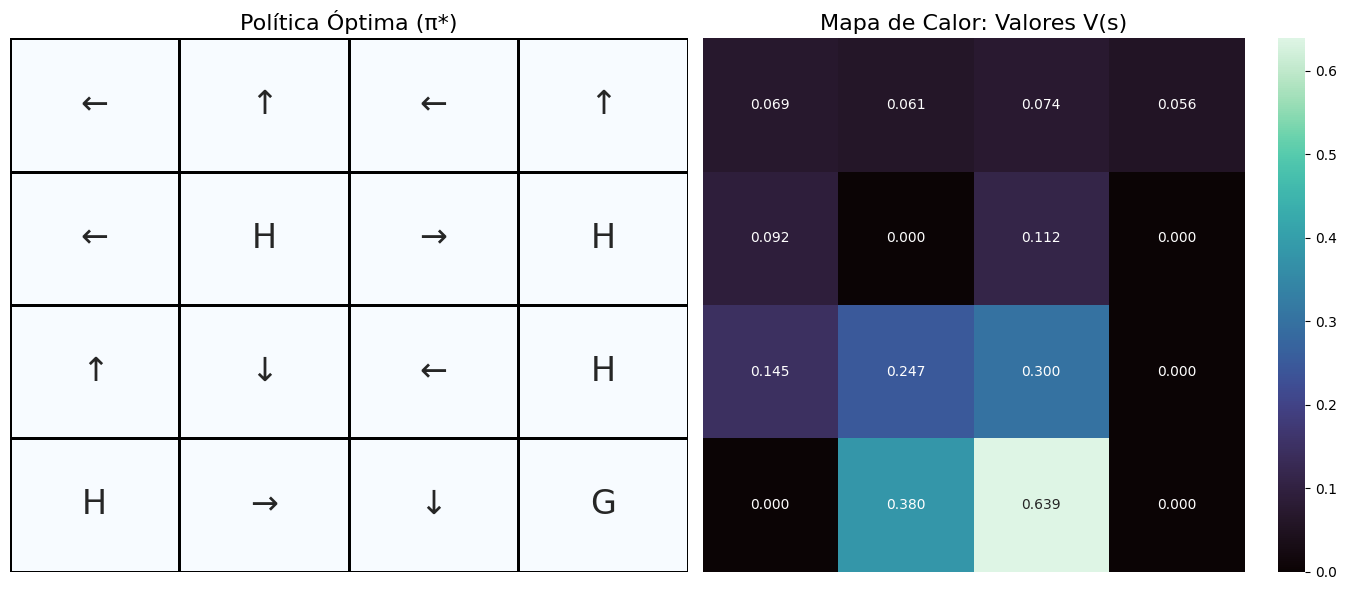

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

arrow_map = {'N': '↑', 'S': '↓', 'E': '→', 'W': '←', 'H': 'H', 'G': 'G'}
visual_policy = np.array([arrow_map.get(action, action) for action in optimal_policy]).reshape(4, 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(np.zeros((4, 4)), annot=visual_policy, fmt="", cmap="Blues", cbar=False, 
            linewidths=1, linecolor='black', ax=axes[0], annot_kws={"size": 24})
axes[0].set_title("Política Óptima (π*)", fontsize=16)
axes[0].axis('off')

sns.heatmap(V_optimal.reshape(4, 4), annot=True, cmap="mako", fmt=".3f", cbar=True, ax=axes[1])
axes[1].set_title("Mapa de Calor: Valores V(s)", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Observando los resultados, nuestro modelo probó ser bastante efectivo. Empezando por las acciones óptimas:

- Podemos ver que en algunos casos toma rutas "extrañas", dónde por ejemplo al iniciar empieza a moverse hacia la izquierda. Esto se debe a que dentro de nuestro modelo, al toparse con una pared "topa" y regresa al estado original. Tomando como ejemplo esta misma celda:
    - Si nos movemos hacia abajo, tenemos un tercio de probabilidad de caer en un hoyo
    - Si nos movemos hacia la derecha, tenemos un tercio de probabilidad de caer en un hoyo
    - Si nos movemos hacia la izquierda, tenemos 2/3 de probabilidad de permanecer en el mismo estado pero 1/3 de transicionar hacia el estado de abajo.
    - Lo  mismo sucede con el movimiento hacia arriba, sin embargo observando el mapa de calor podemos ver que el estado 4 tiene un valor más alto que el 1.

- También podemos darnos cuenta, que casi nunca se toman rutas "directas" hacia el objetivo. La mayoría de veces nuestro modelo toma rutas "indirectas" basándose en las probabilidades de transición y el valor esperado de cada acción.

Por lo tanto, podemos decir que el modelo fue implementado de manera exitosa y logró encontrar rutas óptimas basado en los frameworks vistos en clase.

Por otro lado, tenemos los mapas de calores. Podemos notar lo siguiente:

-  En cada estado "terminal", el valor de Vs es 0. Esto se debe a que diseñamos el MDP con estos estados "absorbentes", para que por ejemplo el modelo no pudiera recibir rewards infinitos topándose con el borde de meta.

- Los estados mientras más cerca están de la meta, más valor tienen. Esto se debe a que dejamos un poco menos a la probabilidad, dónde por ejemplo:

    - Para llegar a la meta tomando decisiones óptimas desde el estado 0, tenemos varios puntos dónde podemos aleatoriamente caer en un hoyo.

    - Iniciando desde el estado 14, tenemos una utilidad muy alta ya que no podemos caer en un hoyo directamente y podemos llegar a la meta con 1/3 de probabilidad.

A futuro, podría ser interesante aplicar este problema a un Grid más complejo para poder identificar patrones más complejos o adicionalmente inducir patrones para explorar los comportamientos del modelo.